**Capstone Project — Exploratory Data Analysis**

Research Question: Are income, grocery-list use and other food planning behaviors associated with lower food-at-home (FAH) acquisition among US households?

This notebook cleans and merges the USDA FoodAPS public files, engineers household-level features, analyzes missing values, duplicates and outliers, explores the data visually, and fits a baseline regression model.

Contents
1. Research Understanding
2. Setup
3. Data Understanding
4. Data Cleaning (missing values, imputation, duplicates)
5. Feature Engineering and Merging
6. Outlier Analysis
7. Exploratory Data Analysis
8. Baseline Modeling
9. Findings
10. Next Steps

**1. Research Understanding**

**Question:** Are income, grocery list use and other food planning behaviors associated with lower food-at-home (FAH) acquisition among US households?

**Data:** USDA FoodAPS public use files https://www.ers.usda.gov/data-products/foodaps-national-household-food-acquisition-and-purchase-survey (CSV files. Documentation is also found at this link)

**Why this question is important:**
According to the Project Drawdown website, “More than one-third of all food produced for human consumption is lost or wasted before it can be eaten.” This is a staggering amount of waste. Moreover, the greenhouse gas emissions related to the production and distribution of this wasted food are high and also wasted. These societal losses have enormous impacts at the household and country levels, as well as on the planet as a whole given climate change impacts. Understanding more about which characteristics of households (income and behaviors) are more strongly associated with higher acquisition and thus a higher potential for food waste (in the US but potentially with some generalizability to other similar countries) could help policymakers implement measures to curb waste. For example, perhaps policymakers could use this information to target information campaigns towards households more likely to waste with tips on how to reduce food waste at home.

**USDA National Household Food Acquisition and Purchase Survey User Guide — additional information on the data from the Guide**

> "The National Household Food Acquisition and Purchase Survey (FoodAPS) collected information on foods purchased or otherwise acquired, and the prices and nutrient characteristics of those foods, for a nationally representative sample of U.S. households. Data on factors expected to affect food acquisition decisions, such as household size and composition, demographic characteristics, income, participation in Federal food assistance programs, and dietary restrictions, were also collected."

**Variables**

| Concept | FoodAPS variables |
|---|---|
| Household ID (merge key across files) | HHNUM |
| Survey design | HHWGT, TSSTRATA, TSPSU |
| Primary spending outcome | TOTALPAID, HHSIZE |
| Primary frequency outcome | EVENTID, HHSIZE |
| Income | PCTPOVGUIDEHH_R |
| Grocery-list use | GROCERYLISTFREQ |
| Home meal routines | NDINNERSOUTHH, NMEALSHOME, NMEALSTOGETHER |
| Food security | ADLTFSCAT, FOODSUFFICIENT |
| Food assistance | SNAPNOWHH, WICHH |
| Transportation | ANYVEHICLE, CARACCESS |
| Primary store | PRIMSTOREDIST_D, PRIMSTORETRAVELTIME, PRIMSTORETYPE |
| Area food access | NEARSMSS_DIST, SNAP3, SM3, SS3, CS3 |
| Geography | REGION, RURAL, NONMETRO |
| Timing | STARTMON |
| FAH behavior extensions | FREE, EBT_SNAP, WIC, PLACETYPE, DAYNUM |

**Datasets** (in Data/CSV_data_files/)
- faps_household_puf.csv: one row per household
- faps_fahevent_puf.csv: one row per food-at-home acquisition event (ex: a shopping trip)
- faps_access_puf.csv: one row per household, describing the local food environment

**2. Setup**

**Import libraries and load the data**

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

data_dir = Path('Data/CSV_data_files')

household = pd.read_csv(data_dir / 'faps_household_puf.csv')
fahevent  = pd.read_csv(data_dir / 'faps_fahevent_puf.csv')
access    = pd.read_csv(data_dir / 'faps_access_puf.csv')

**3. Data Understanding**

**Keep only the variables of interest to the research from each dataset**

In [2]:
household_columns = ['hhnum', 'hhwgt', 'tspsu', 'tsstrata', 'hhsize', 'pctpovguidehh_r', 'grocerylistfreq',
                     'ndinnersouthh', 'nmealshome', 'nmealstogether', 'adltfscat', 'foodsufficient',
                     'snapnowhh', 'wichh', 'anyvehicle', 'caraccess', 'primstoredist_d', 'primstoretraveltime',
                     'primstoretype', 'region', 'rural', 'nonmetro', 'startmon']
fahevent_columns = ['hhnum', 'eventid', 'totalpaid', 'free', 'ebt_snap', 'wic', 'placetype', 'daynum']
access_columns   = ['hhnum', 'nearsmss_dist', 'snap3', 'sm3', 'ss3', 'cs3']

household = household[household_columns]
fahevent  = fahevent[fahevent_columns]
access    = access[access_columns]

overview = pd.DataFrame({
    'dataset': ['household', 'fahevent', 'access'],
    'level': ['one row per household', 'one row per FAH acquisition event', 'one row per household'],
    'rows': [len(household), len(fahevent), len(access)],
    'columns': [household.shape[1], fahevent.shape[1], access.shape[1]],
    'unique households': [household['hhnum'].nunique(), fahevent['hhnum'].nunique(), access['hhnum'].nunique()]})
overview

,dataset,level,rows,columns,unique households
0,household,one row per household,4826,23,4826
1,fahevent,one row per FAH acquisition event,15998,8,4412
2,access,one row per household,4826,6,4826


In [3]:
household.head()

,hhnum,hhwgt,tspsu,tsstrata,hhsize,pctpovguidehh_r,grocerylistfreq,ndinnersouthh,nmealshome,nmealstogether,adltfscat,foodsufficient,snapnowhh,wichh,anyvehicle,caraccess,primstoredist_d,primstoretraveltime,primstoretype,region,rural,nonmetro,startmon
0,100012,6056.913412,14,15,5,207.360089,3,1,9,2,2,2,1,-996,1,-996,0.682,4,122.0,3,1,1,1
1,100015,26741.184558,13,17,1,128.916741,3,-996,5,-996,2,3,0,-996,1,-996,1.352,5,122.0,3,0,0,8
2,100024,31665.579066,12,7,2,398.506279,2,0,3,2,2,2,0,-996,1,-996,1.208,3,121.0,2,0,0,6
3,100026,5686.761977,35,14,2,142.762723,1,2,7,21,3,2,0,-996,1,-996,4.358,5,111.0,3,1,0,7
4,100028,1067.431417,51,24,7,137.348984,2,0,7,3,4,3,1,1,1,-996,1.548,15,122.0,1,0,0,5


We notice there are coded values such as **-996** that represent missing or skipped answers. These are handled in the cleaning section.

In [4]:
fahevent.head()

,hhnum,eventid,totalpaid,free,ebt_snap,wic,placetype,daynum
0,100012,65792,1.80,0.0,0.0,0.0,122,2
1,100012,66220,22.39,0.0,0.0,0.0,122,3
2,100012,66221,9.62,0.0,0.0,0.0,122,4
3,100012,66222,39.75,0.0,0.0,0.0,122,5
4,100012,66485,54.67,0.0,0.0,0.0,122,6


In [5]:
access.head()

,hhnum,nearsmss_dist,snap3,sm3,ss3,cs3
0,100012,0.33,9,1,1,0
1,100015,0.94,18,0,1,10
2,100024,0.92,2,0,1,0
3,100026,8.05,0,0,0,0
4,100028,1.17,12,0,0,7


In [3]:
#Data types by dataset
pd.DataFrame({'household': household.dtypes.value_counts(),
              'fahevent': fahevent.dtypes.value_counts(),
              'access': access.dtypes.value_counts()}).fillna(0).astype(int)

,household,fahevent,access
int64,19,4,5
float64,4,4,1


**4. Data Cleaning**

**4.1 Recode missing-value codes**
FoodAPS uses negative codes for non-responses:
- -996 Valid skip
- -997 Don't know
- -998 Refused
- -999 Missing

In [4]:
missing_codes = [-996, -997, -998, -999]

#Recode all columns for missing values except the key and survey design features
keys = {'hhnum', 'tspsu', 'tsstrata'}

#Function to recode the missing codes above to NaN
def recode_missing(df, missing_codes=missing_codes, exclude=keys):
    df = df.copy()
    numeric_cols = [column for column in df.select_dtypes(include=[np.number]).columns if column not in exclude]
    df[numeric_cols] = df[numeric_cols].where(~df[numeric_cols].isin(missing_codes), np.nan)
    return df

#Apply the recode function to numeric columns
household_clean = recode_missing(household)
access_clean    = recode_missing(access)
fahevent_clean  = recode_missing(fahevent)


**4.2 Inspect the missing values**

In [6]:
#Summarize missing values
def missing_summary(df, name):
    counts = df.isna().sum()
    summary = pd.DataFrame({'dataset': name, 'missing': counts, 'percent missing': (100 * counts / len(df)).round(1)})
    return summary[summary['missing'] > 0]

missing_before = pd.concat([missing_summary(household_clean, 'household'),
                           missing_summary(fahevent_clean, 'fahevent'),
                            missing_summary(access_clean, 'access')]).sort_values('percent missing', ascending=False)
missing_before

,dataset,missing,percent missing
caraccess,household,4440,92.0
wichh,household,3819,79.1
ndinnersouthh,household,1010,20.9
nmealstogether,household,1005,20.8
ebt_snap,fahevent,1471,9.2
wic,fahevent,1471,9.2
primstoredist_d,household,317,6.6
totalpaid,fahevent,156,1.0
free,fahevent,91,0.6
primstoretype,household,22,0.5


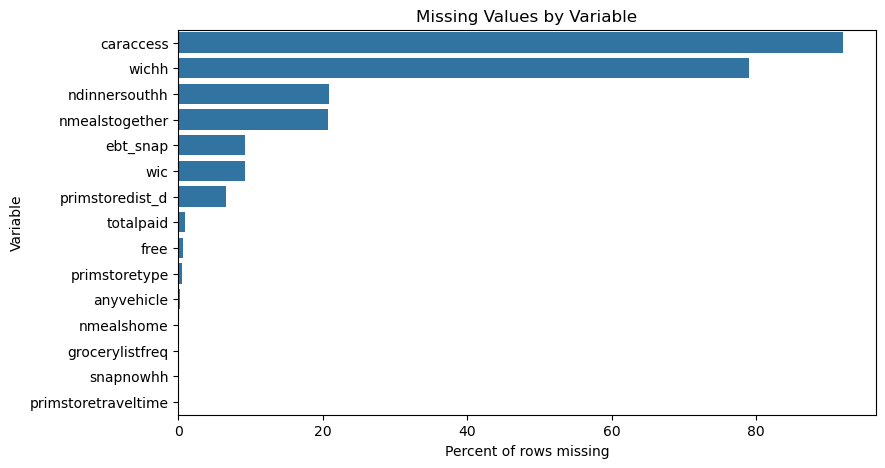

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = missing_before.reset_index().rename(columns={'index': 'variable'})
sns.barplot(data=plot_data, y='variable', x='percent missing', dodge=False, ax=ax)
ax.set_title('Missing Values by Variable')
ax.set_xlabel('Percent of rows missing')
ax.set_ylabel('Variable')
plt.show()

**4.3 Household data imputations**

In [17]:
household_imputed = household_clean.copy()

#caraccess to separate those who have a vehicle vs. no vehicle but access to one vs. no vehicle and no access
household_imputed['caraccess_categorical'] = np.select(
    condlist=[household_imputed['anyvehicle'] == 1,
              (household_imputed['anyvehicle'] == 0) & (household_imputed['caraccess'] == 1),
              (household_imputed['anyvehicle'] == 0) & (household_imputed['caraccess'] == 0)],
    choicelist=['has_vehicle', 'no_vehicle_has_access', 'no_vehicle_no_access'], default=None)

#wichh (households without a WIC-eligible member were skipped (-996 "valid skip"), so they do not receive WIC - assign 0)
household_imputed.loc[household['wichh'] == -996, 'wichh'] = 0

#ndinnersouthh & nmealstogether (for a one person household "meals together" is not meaningful, so recode the skip to 0)
mask_dinners = (household['ndinnersouthh'] == -996) & (household_imputed['hhsize'] == 1)
household_imputed.loc[mask_dinners, 'ndinnersouthh'] = 0
mask_together = (household['nmealstogether'] == -996) & (household_imputed['hhsize'] == 1)
household_imputed.loc[mask_together, 'nmealstogether'] = 0

#primstoredist_d: impute the average distance
household_imputed['primstoredist_d'] = household_imputed['primstoredist_d'].fillna(household_imputed['primstoredist_d'].mean())

missing_summary(household_imputed, 'household').sort_values('missing', ascending=False)

,dataset,missing,percent missing
caraccess,household,4440,92.0
caraccess_categorical,household,493,10.2
primstoretype,household,22,0.5
anyvehicle,household,10,0.2
ndinnersouthh,household,6,0.1
nmealshome,household,4,0.1
snapnowhh,household,2,0.0
primstoretraveltime,household,2,0.0
grocerylistfreq,household,1,0.0
nmealstogether,household,1,0.0


We have reduced the number of missing values. The few that remain are handled later inside the modeling pipeline

**4.4 FAH event data imputations**

In [19]:
fahevent_imputed = fahevent_clean.copy()

#totalpaid: flag imputed rows, then fill with the average spending for the same place type
fahevent_imputed['totalpaid_imputed'] = fahevent_imputed['totalpaid'].isna().astype(int)
fahevent_imputed['totalpaid'] = fahevent_imputed.groupby('placetype')['totalpaid'].transform(lambda s: s.fillna(s.mean()))

missing_summary(fahevent_imputed, 'fahevent')

,dataset,missing,percent missing
free,fahevent,91,0.6
ebt_snap,fahevent,1471,9.2
wic,fahevent,1471,9.2


**4.5 Check for duplicate records**

In [20]:
#Fully duplicated rows and duplicated keys in each dataset
duplicate_check = pd.DataFrame({
    'dataset': ['household', 'fahevent', 'access'],
    'duplicate rows': [household_imputed.duplicated().sum(), fahevent_imputed.duplicated().sum(), access_clean.duplicated().sum()],
    'key': ['hhnum', 'hhnum + eventid', 'hhnum'],
    'duplicate keys': [household_imputed['hhnum'].duplicated().sum(),
                       fahevent_imputed.duplicated(subset=['hhnum', 'eventid']).sum(),
                       access_clean['hhnum'].duplicated().sum()]})
duplicate_check

,dataset,duplicate rows,key,duplicate keys
0,household,0,hhnum,0
1,fahevent,0,hhnum + eventid,0
2,access,0,hhnum,0


No duplicates present in the datasets

**5. Feature Engineering and Merging**

**5.1 Aggregate the FAH events to the household level**
The FAH event file is at the single event level (Ex: one shopping trip), so aggregate up to the household level before merging with the household data.

In [22]:
#Create aggregated features
fah_agg = fahevent_imputed.groupby('hhnum').agg(
    #total spending
    fah_total_spending=('totalpaid', 'sum'),  
    #number of events        
    fah_event_count=('eventid', 'count'), 
    #average spending per event            
    fah_avg_spend_event=('totalpaid', 'mean'), 
    #distinct acquisition days       
    fah_acquisition_days=('daynum', 'nunique'), 
    #no cost events      
    fah_free_event_count=('free', 'sum'), 
    #events with free flag reported            
    fah_free_reported_number=('free', 'count'),  
    #SNAP events     
    fah_snap_event_count=('ebt_snap', 'sum'), 
    #events with SNAP flag reported        
    fah_snap_reported_number=('ebt_snap', 'count'), 
    #WIC events  
    fah_wic_event_count=('wic', 'sum'),     
    #events with WIC flag reported          
    fah_wic_reported_number=('wic', 'count'),
    #distinct place types food was acquired from        
    fah_number_placetypes=('placetype', 'nunique')   
).reset_index()

#Percent of free SNAP and WIC acquisition events
fah_agg['fah_pct_free_events'] = fah_agg['fah_free_event_count'] / fah_agg['fah_free_reported_number']
fah_agg['fah_pct_snap_events'] = fah_agg['fah_snap_event_count'] / fah_agg['fah_snap_reported_number']
fah_agg['fah_pct_wic_events']  = fah_agg['fah_wic_event_count'] / fah_agg['fah_wic_reported_number']

#Delete columns used only for the percent calculations
fah_agg = fah_agg.drop(columns=['fah_free_reported_number', 'fah_snap_reported_number', 'fah_wic_reported_number'])


**5.2 Merge all three datasets**
We want the data at the household level with a one to one mapping between the household data, the aggregated FAH data and the access data.

In [23]:
df = household_imputed.merge(fah_agg, on='hhnum', how='left', validate='one_to_one')
df = df.merge(access_clean, on='hhnum', how='left', validate='one_to_one')

#Households that reported no FAH events during the survey week get NaN from the left merge
count_columns = ['fah_total_spending', 'fah_event_count', 'fah_avg_spend_event', 'fah_acquisition_days',
                 'fah_free_event_count', 'fah_snap_event_count', 'fah_wic_event_count', 'fah_number_placetypes']
print('Households with no FAH events', df['fah_event_count'].isna().sum())
df[df['fah_event_count'].isna()][['hhnum', 'hhsize'] + count_columns].head()

Households with no FAH events 414


,hhnum,hhsize,fah_total_spending,fah_event_count,fah_avg_spend_event,fah_acquisition_days,fah_free_event_count,fah_snap_event_count,fah_wic_event_count,fah_number_placetypes
16,100073,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,100197,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,100262,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,100284,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,100286,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


These NaNs are not truly missing. They are households with no events in that category so they are filled with zeros

In [26]:
#Fill the NaNs with zeros
df[count_columns] = df[count_columns].fillna(0)

#double check there are no remaining NaNs
df[df['fah_event_count'].isna()][['hhnum', 'hhsize'] + count_columns].head()

,hhnum,hhsize,fah_total_spending,fah_event_count,fah_avg_spend_event,fah_acquisition_days,fah_free_event_count,fah_snap_event_count,fah_wic_event_count,fah_number_placetypes


**5.3 Create additional features**
Rename variables to readable names, normalize acquisition by household size, and build food-insecurity, season, region and car-access features

In [27]:
#Variables to keep
analysis_columns = {
    'hhnum': 'hhnum', 'hhwgt': 'hhwgt', 'tspsu': 'tspsu', 'tsstrata': 'tsstrata',
    'fah_total_spending': 'fah_total_spending', 'fah_event_count': 'fah_event_count',
    'fah_avg_spend_event': 'fah_avg_spend_event', 'fah_acquisition_days': 'fah_acquisition_days',
    'fah_pct_free_events': 'fah_pct_free_events', 'fah_pct_snap_events': 'fah_pct_snap_events',
    'fah_pct_wic_events': 'fah_pct_wic_events', 'fah_number_placetypes': 'fah_number_placetypes',
    'hhsize': 'hhsize',
    'pctpovguidehh_r': 'income_pct_poverty',
    'grocerylistfreq': 'grocery_list_freq',
    'ndinnersouthh': 'n_dinners_out', 'nmealshome': 'n_meals_home', 'nmealstogether': 'n_meals_together',
    'adltfscat': 'food_security_cat', 'foodsufficient': 'food_sufficient_cat',
    'snapnowhh': 'snap_now', 'wichh': 'wic_hh',
    'caraccess_categorical': 'caraccess_categorical',
    'primstoredist_d': 'primstore_dist', 'primstoretraveltime': 'primstore_traveltime', 'primstoretype': 'primstore_type',
    'nearsmss_dist': 'near_supermkt_dist', 'snap3': 'snap_stores_3mi', 'sm3': 'supermkt_3mi',
    'ss3': 'supercenter_3mi', 'cs3': 'convenience_3mi',
    'region': 'region', 'rural': 'rural', 'nonmetro': 'nonmetro', 'startmon': 'start_month'}

analysis_df = df[list(analysis_columns.keys())].rename(columns=analysis_columns)

#acquisition intensity normalized by household size
analysis_df['fah_spending_pc'] = analysis_df['fah_total_spending'] / analysis_df['hhsize']
analysis_df['fah_events_pc']   = analysis_df['fah_event_count'] / analysis_df['hhsize']

#food insecurity and income features
analysis_df['food_insecure'] = analysis_df['food_security_cat'].isin([3, 4]).astype(int)
#create income as a multiple of the poverty line feature
analysis_df['income_x_poverty'] = analysis_df['income_pct_poverty'] / 100.0

#season from the survey start month
seasons = {12: 'winter', 1: 'winter', 2: 'winter', 3: 'spring', 4: 'spring', 5: 'spring',
           6: 'summer', 7: 'summer', 8: 'summer', 9: 'fall', 10: 'fall', 11: 'fall'}
analysis_df['season'] = analysis_df['start_month'].map(seasons)

#clean car access variable
analysis_df['caraccess_categorical'] = analysis_df['caraccess_categorical'].fillna('unknown')

#regions variable creation
regions = {1: 'northeast', 2: 'midwest', 3: 'south', 4: 'west'}
analysis_df['region_lbl'] = analysis_df['region'].map(regions)

#labels for EDA plots
grocery_labels = {1: 'Never', 2: 'Seldom', 3: 'Sometimes', 4: 'Most of the time', 5: 'Almost always'}
food_security_labels = {1: 'High', 2: 'Marginal', 3: 'Low', 4: 'Very low'}
analysis_df['grocery_list_lbl'] = pd.Categorical(analysis_df['grocery_list_freq'].map(grocery_labels),
                                                 categories=list(grocery_labels.values()), ordered=True)
analysis_df['food_security_lbl'] = pd.Categorical(analysis_df['food_security_cat'].map(food_security_labels),
                                                  categories=list(food_security_labels.values()), ordered=True)

#income groups relative to the federal poverty line
#note: 185% is the WIC and reduced price school meal cutoff
analysis_df['income_group'] = pd.cut(analysis_df['income_pct_poverty'], bins=[-np.inf, 100, 185, 300, np.inf],
                                     labels=['<100 percent FPL', '100-185 percent FPL', '185-300 percent FPL', '300+ percent FPL'])

#create cummy features: season, region, car access with reference categories dropped
dummy_init = [('caraccess_categorical', 'has_vehicle'), ('region_lbl', 'south'), ('season', 'summer')]
dummy_frame = []
for col, ref in dummy_init:
    d = pd.get_dummies(analysis_df[col], prefix=col, drop_first=False).astype(int)
    d = d.drop(columns=[f'{col}_{ref}'])
    dummy_frame.append(d)
analysis_df = pd.concat([analysis_df] + dummy_frame, axis=1)

#log transformation of the skewed outcomes
#note: using log1p because some households have zero spending or events
analysis_df['log_fah_spending'] = np.log1p(analysis_df['fah_spending_pc'])
analysis_df['log_fah_events']   = np.log1p(analysis_df['fah_events_pc'])

analysis_df.head()

,hhnum,hhwgt,tspsu,tsstrata,fah_total_spending,fah_event_count,fah_avg_spend_event,fah_acquisition_days,fah_pct_free_events,fah_pct_snap_events,...,caraccess_categorical_no_vehicle_no_access,caraccess_categorical_unknown,region_lbl_midwest,region_lbl_northeast,region_lbl_west,season_fall,season_spring,season_winter,log_fah_spending,log_fah_events
0,100012,6056.913412,14,15,133.57,6.0,22.261667,5.0,0.000000,0.0,...,0,0,0,0,0,0,0,1,3.321938,0.788457
1,100015,26741.184558,13,17,40.56,6.0,6.760000,4.0,0.000000,0.0,...,0,0,0,0,0,0,0,0,3.727138,1.945910
2,100024,31665.579066,12,7,82.97,3.0,27.656667,2.0,0.000000,0.0,...,0,0,1,0,0,0,0,0,3.749151,0.916291
3,100026,5686.761977,35,14,122.95,9.0,13.661111,5.0,0.333333,0.0,...,0,0,0,0,0,0,0,0,4.134766,1.704748
4,100028,1067.431417,51,24,88.99,7.0,12.712857,6.0,0.000000,0.0,...,0,0,0,1,0,0,1,0,2.618334,0.693147


**6. Outlier Analysis**
Look for anomalies in the main outcome and in the key continuous predictors using boxplots and the 1.5 × IQR rule.

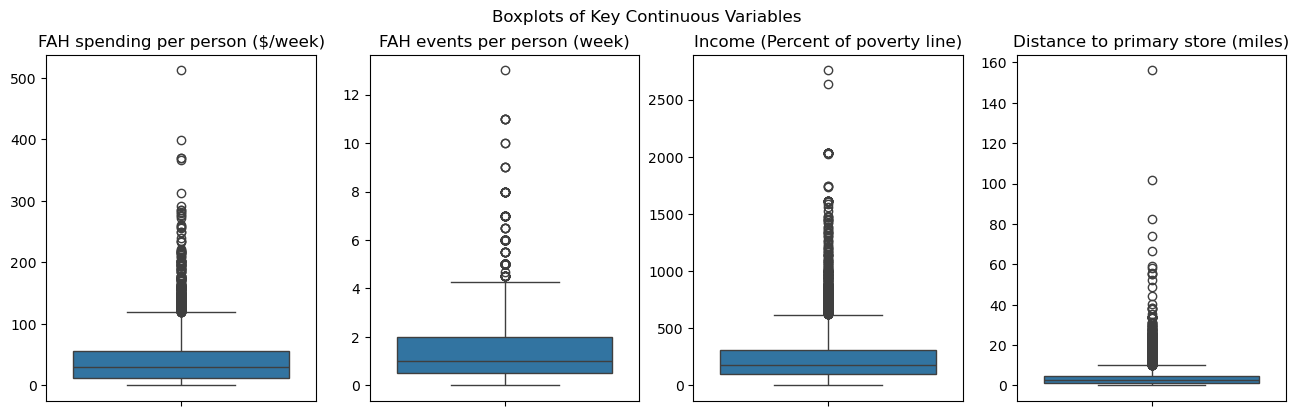

In [28]:
#variables to plot and check for outliers
outlier_vars = {'fah_spending_pc': 'FAH spending per person ($/week)',
                'fah_events_pc': 'FAH events per person (week)',
                'income_pct_poverty': 'Income (Percent of poverty line)',
                'primstore_dist': 'Distance to primary store (miles)'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (col, label) in zip(axes, outlier_vars.items()):
    sns.boxplot(y=analysis_df[col], ax=ax)
    ax.set_title(label)
    ax.set_ylabel('')
fig.suptitle('Boxplots of Key Continuous Variables')
plt.show()

In [29]:
#Count IQR outliers for each variable
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (series < lower) | (series > upper)
    return pd.Series({'lower bound': round(lower, 1), 'upper bound': round(upper, 1),
                      'number of outliers': int(is_outlier.sum()), 'percent of outliers': round(100 * is_outlier.mean(), 1),
                      'median': round(series.median(), 1), 'max': round(series.max(), 1)})

outlier_table = pd.DataFrame({label: iqr_outliers(analysis_df[col].dropna()) for col, label in outlier_vars.items()}).T
outlier_table

,lower bound,upper bound,number of outliers,percent of outliers,median,max
FAH spending per person ($/week),-51.4,119.4,235.0,4.9,30.3,512.4
FAH events per person (week),-1.8,4.2,179.0,3.7,1.0,13.0
Income (Percent of poverty line),-209.9,618.0,330.0,6.8,174.5,2755.6
Distance to primary store (miles),-4.0,10.0,487.0,10.1,2.6,156.1


We keep outliers because they represent households that spent nothing or spent a lot in a given week, all of which are of interest.

**7. Exploratory Data Analysis**

**7.1 Distribution of the outcome variables**

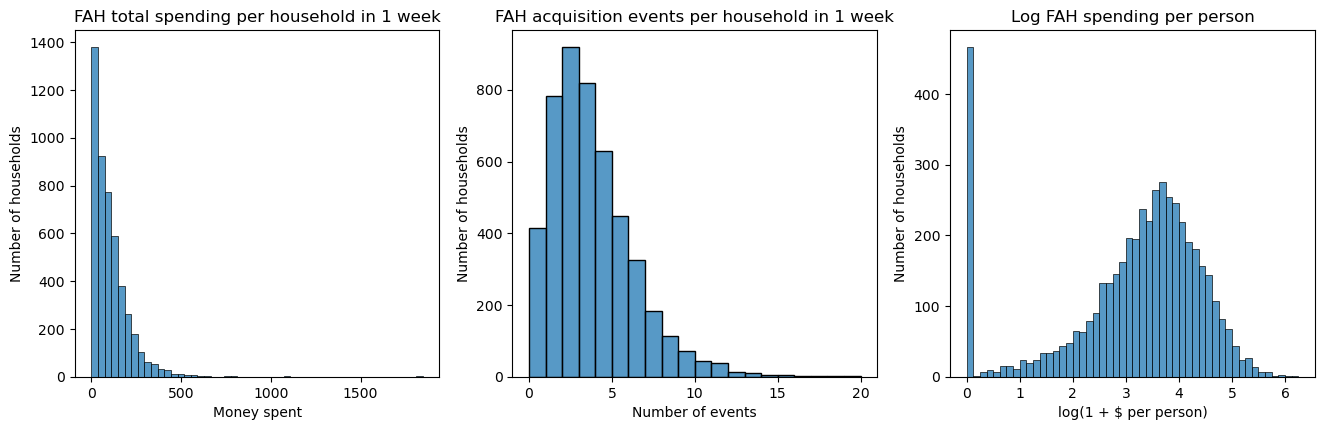

In [30]:
#Create plots of the outcome variables
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(analysis_df['fah_total_spending'], bins=50, ax=axes[0])
axes[0].set_title('FAH total spending per household in 1 week')
axes[0].set_xlabel('Money spent')
axes[0].set_ylabel('Number of households')

sns.histplot(analysis_df['fah_event_count'], bins=20, ax=axes[1])
axes[1].set_title('FAH acquisition events per household in 1 week')
axes[1].set_xlabel('Number of events')
axes[1].set_ylabel('Number of households')

sns.histplot(analysis_df['log_fah_spending'], bins=50, ax=axes[2])
axes[2].set_title('Log FAH spending per person')
axes[2].set_xlabel('log(1 + $ per person)')
axes[2].set_ylabel('Number of households')

plt.show()

Both raw outcomes are right-skewed. Using log1p (log of 1 + x), since many households have 0 spending.

**7.2 Categorical variables**

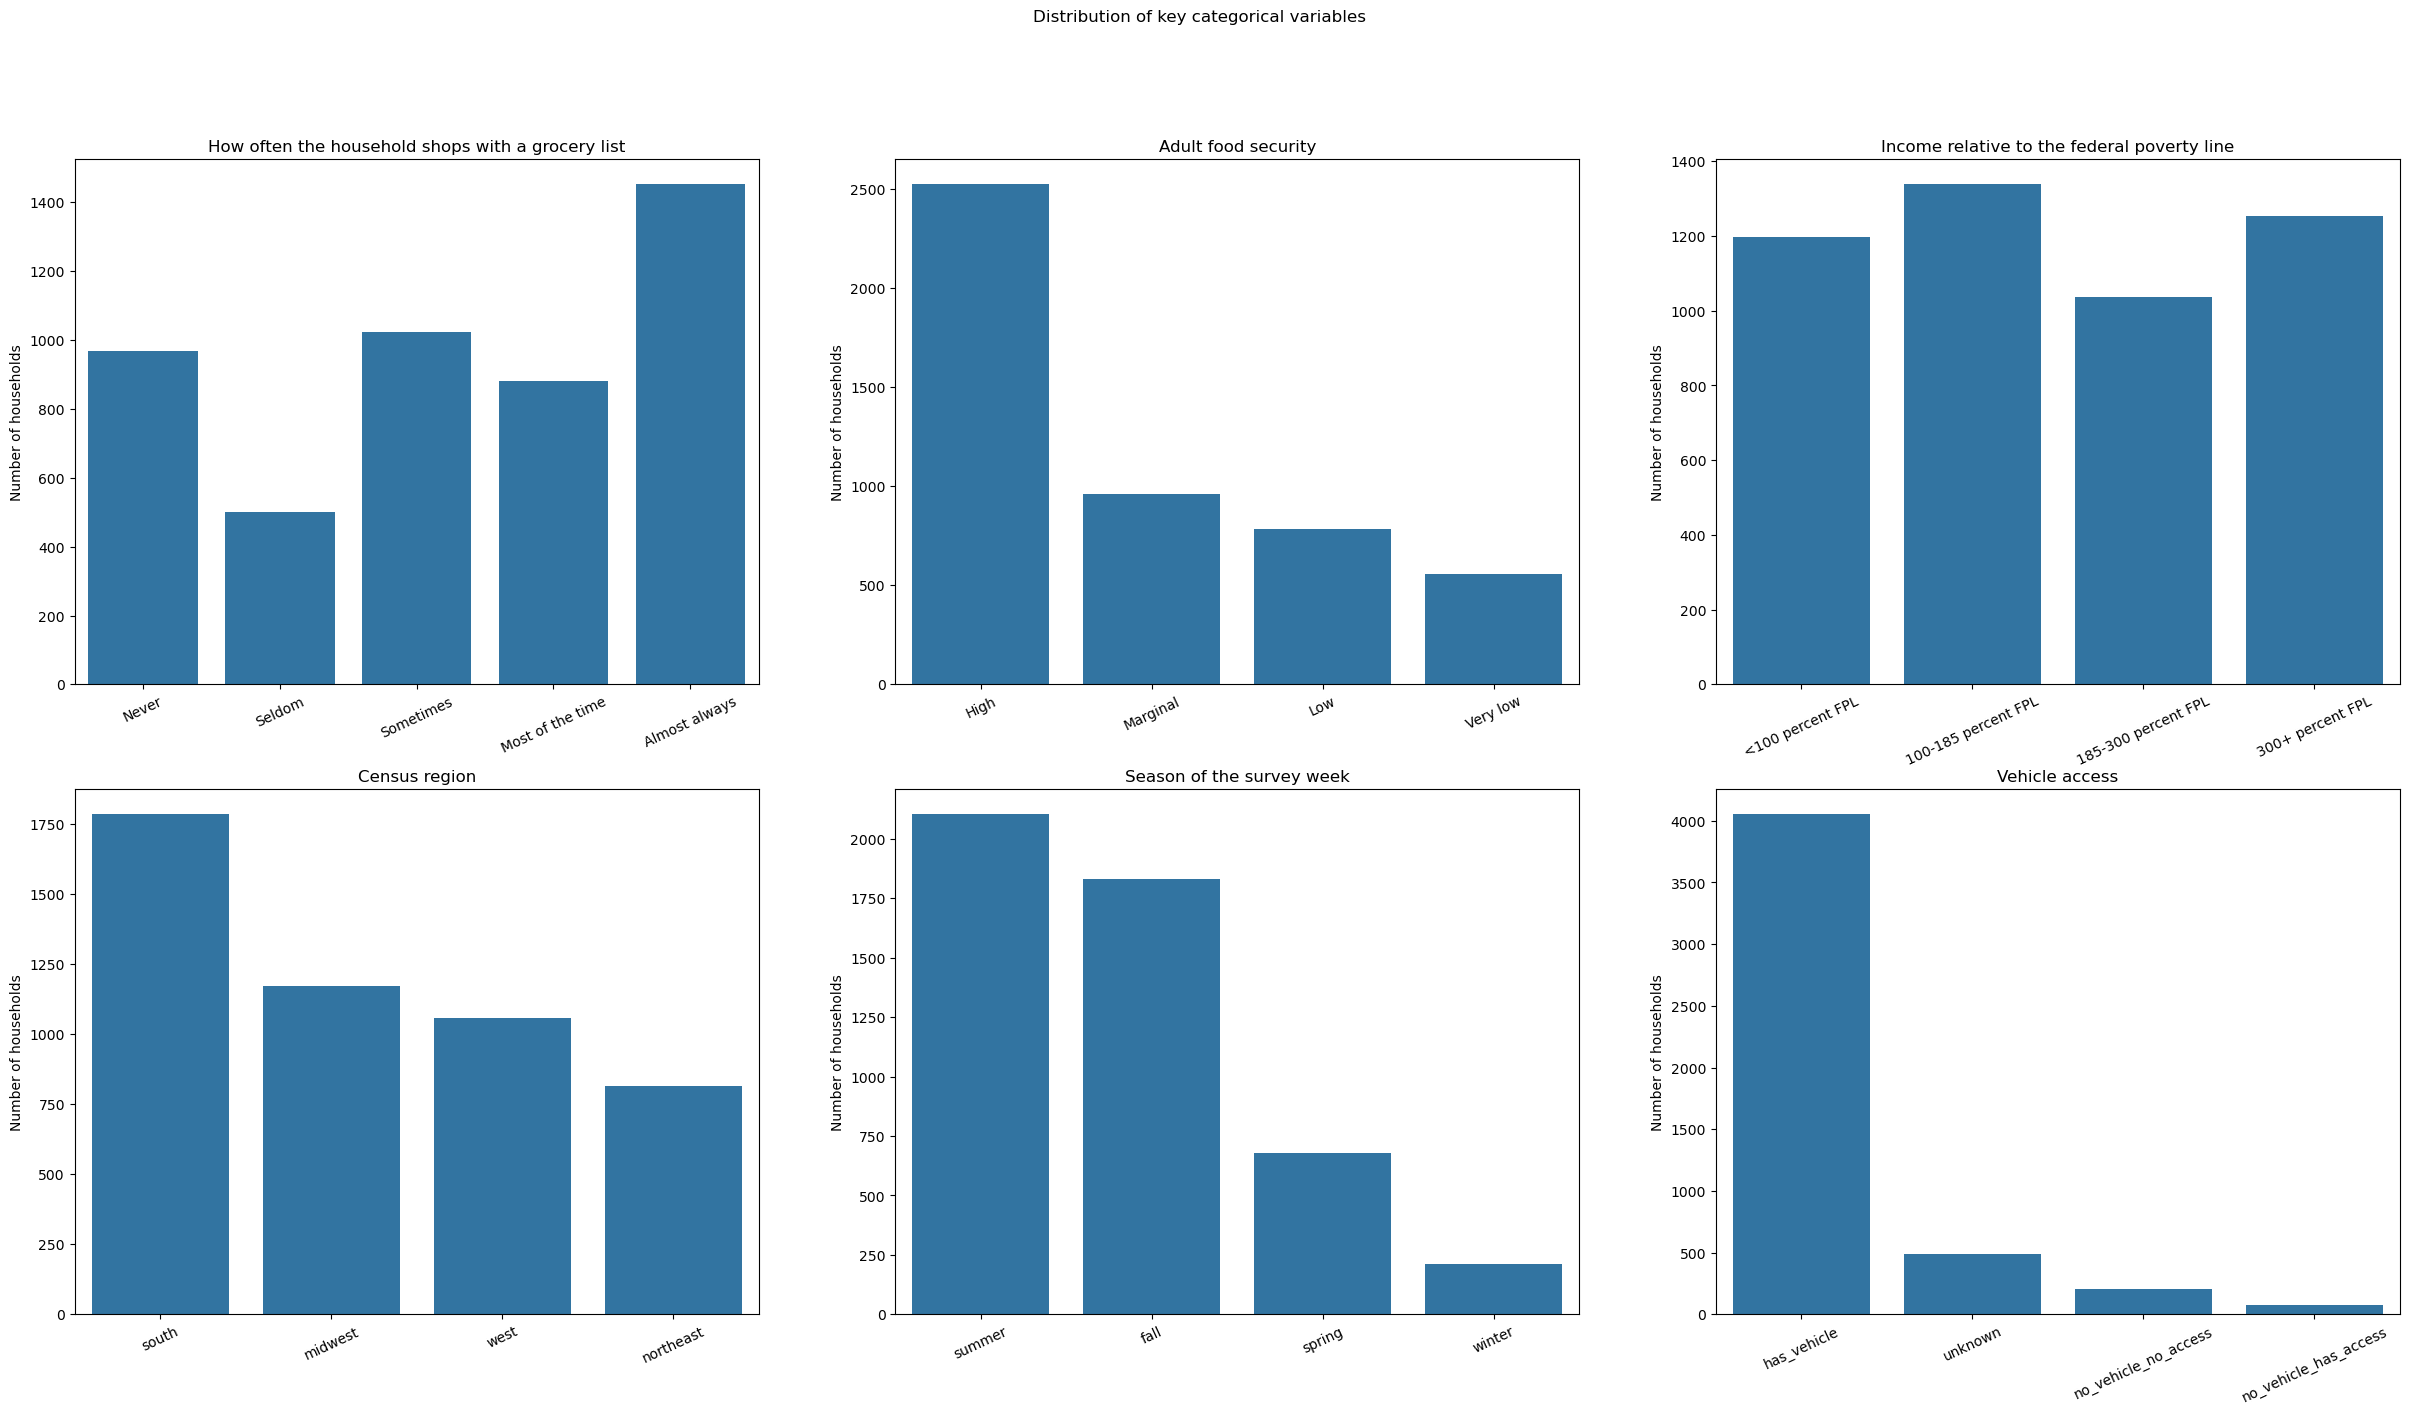

In [31]:
#create plots of the categorical variables of interest
categorical_plots = [('grocery_list_lbl', 'How often the household shops with a grocery list'),
                     ('food_security_lbl', 'Adult food security'),
                     ('income_group', 'Income relative to the federal poverty line'),
                     ('region_lbl', 'Census region'),
                     ('season', 'Season of the survey week'),
                     ('caraccess_categorical', 'Vehicle access')]

fig, axes = plt.subplots(2, 3, figsize=(30,15))
for ax, (col, title) in zip(axes.flat, categorical_plots):
    order = analysis_df[col].cat.categories if hasattr(analysis_df[col], 'cat') else analysis_df[col].value_counts().index
    sns.countplot(data=analysis_df, x=col, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Number of households')
    ax.tick_params(axis='x', rotation=25)
fig.suptitle('Distribution of key categorical variables')

plt.show()

**7.3 FAH spending across income and food-planning groups**

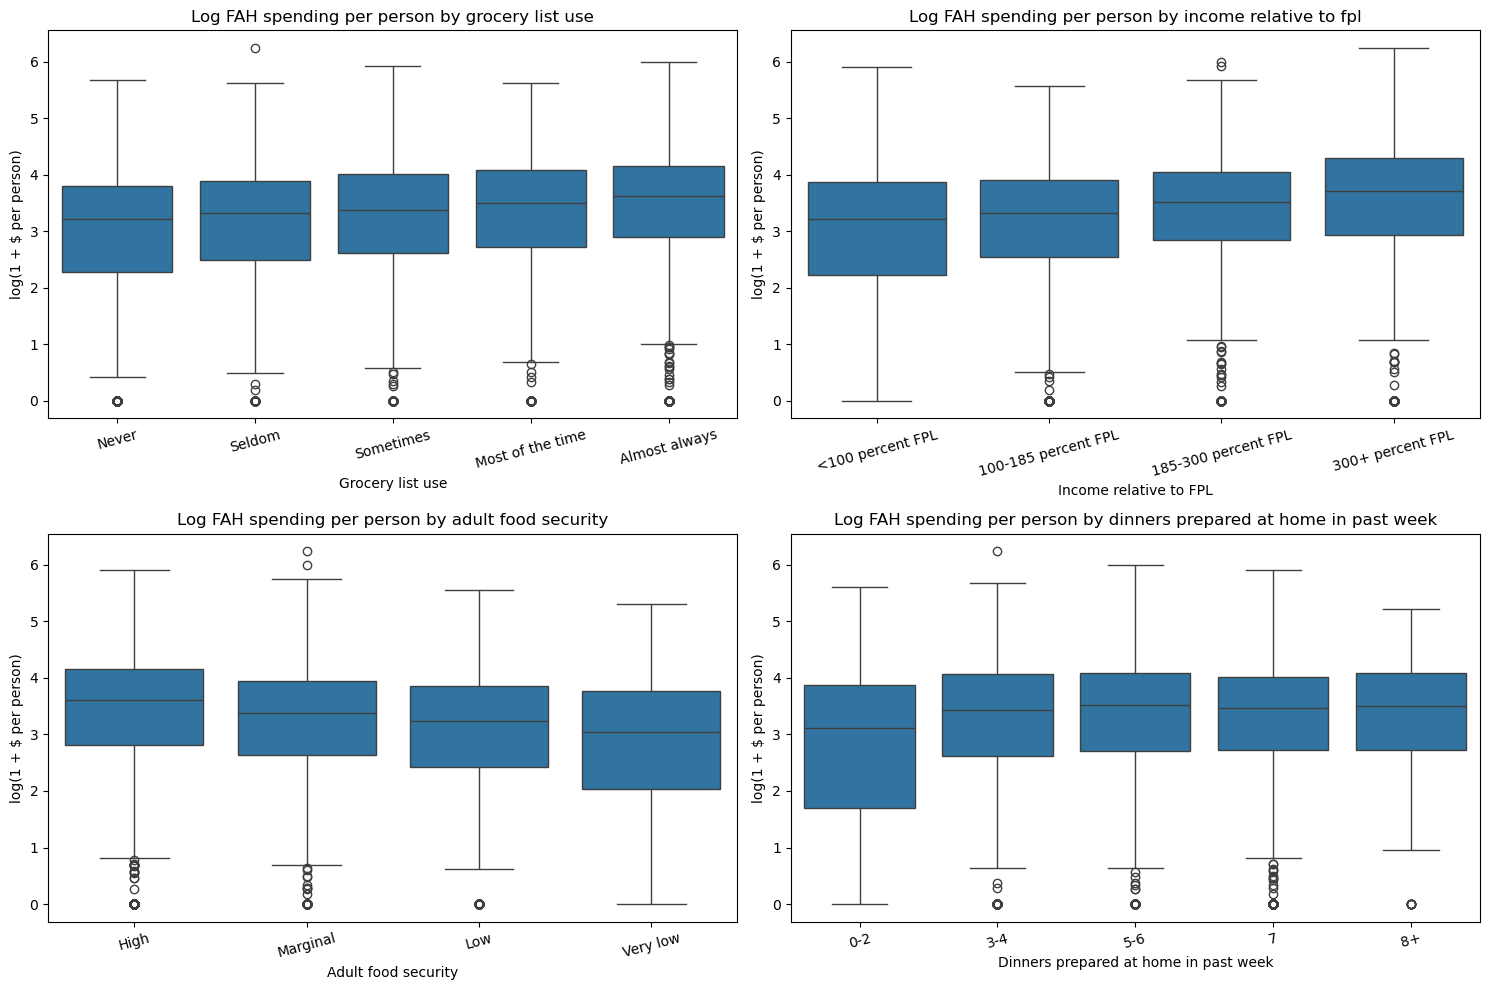

In [33]:
#bin meals prepared at home into groups for plotting
analysis_df['meals_home_group'] = pd.cut(analysis_df['n_meals_home'], bins=[-1, 2, 4, 6, 7, np.inf], labels=['0-2', '3-4', '5-6', '7', '8+'])

group_plots = [('grocery_list_lbl', 'Grocery list use'),
               ('income_group', 'Income relative to FPL'),
               ('food_security_lbl', 'Adult food security'),
               ('meals_home_group', 'Dinners prepared at home in past week')]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (col, title) in zip(axes.flat, group_plots):
    sns.boxplot(data=analysis_df, x=col, y='log_fah_spending', ax=ax)
    ax.set_title(f'Log FAH spending per person by {title.lower()}')
    ax.set_xlabel(title)
    ax.set_ylabel('log(1 + $ per person)')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

**Key EDA pattern:**

These relationships run opposite to the hypothesis that planning behaviors go with lower acquisition. Households that plan with lists, cook at home more, and have higher incomes acquire more food at home. Part of this is likely confounding (list use and cooking at home both rise with income), so the models will estimate each variable while holding the others constant.

**7.4 Continuous relationships**

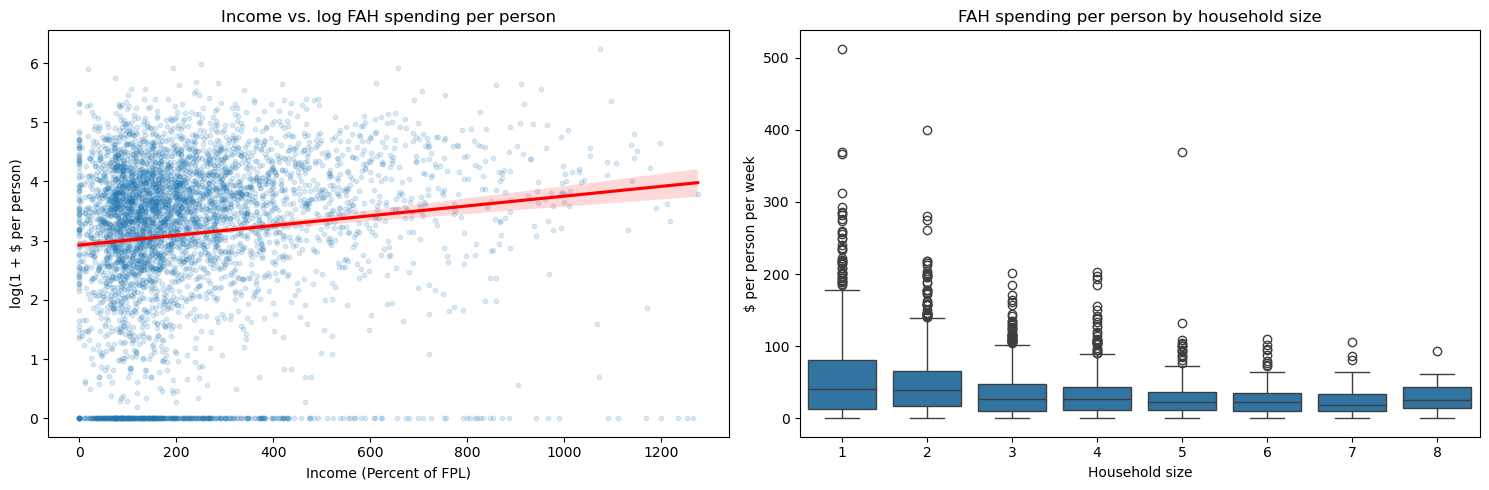

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Income vs spending plot
#limit x axis to 99th percentile
income_cap = analysis_df['income_pct_poverty'].quantile(0.99)
plot_df = analysis_df[analysis_df['income_pct_poverty'] <= income_cap]
sns.regplot(data=plot_df, x='income_pct_poverty', y='log_fah_spending', ax=axes[0],
            scatter_kws={'alpha': 0.15, 's': 10}, line_kws={'color': 'red'})
axes[0].set_title('Income vs. log FAH spending per person')
axes[0].set_xlabel('Income (Percent of FPL)')
axes[0].set_ylabel('log(1 + $ per person)')

#Household size vs spending per person plot
sns.boxplot(data=analysis_df[analysis_df['hhsize'] <= 8], x='hhsize', y='fah_spending_pc', ax=axes[1])
axes[1].set_title('FAH spending per person by household size')
axes[1].set_xlabel('Household size')
axes[1].set_ylabel('$ per person per week')

plt.tight_layout()
plt.show()

Income has a positive but weak relationship with log spending per person

**7.5 Correlation matrix**

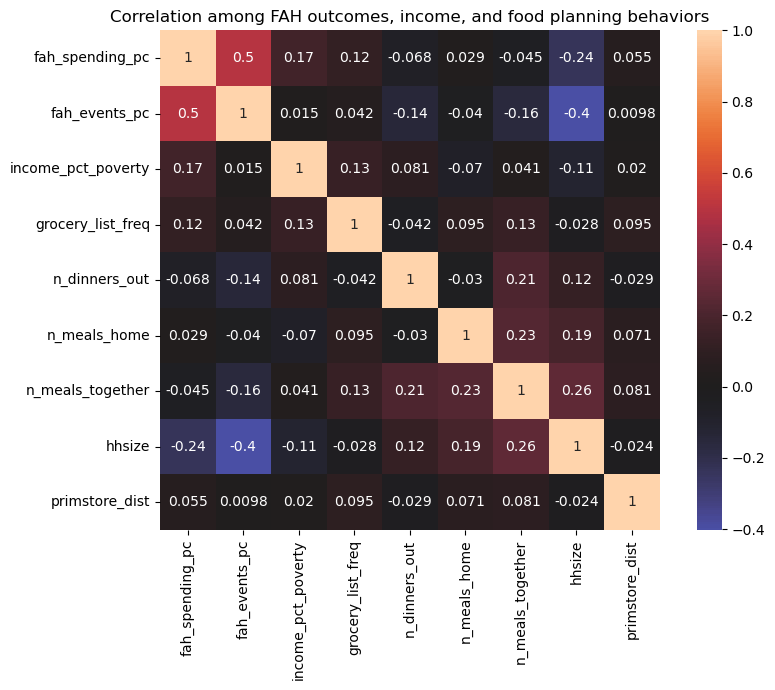

In [39]:
corr_columns = ['fah_spending_pc', 'fah_events_pc', 'income_pct_poverty', 'grocery_list_freq', 'n_dinners_out',
                'n_meals_home', 'n_meals_together', 'hhsize', 'primstore_dist']
corr = analysis_df[corr_columns].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, center=0, ax=ax, square=True)
ax.set_title('Correlation among FAH outcomes, income, and food planning behaviors')
plt.tight_layout()
plt.show()

The FAH events and FAH spending variables are moderately correlated but not redundant, since people can acquire the same amount of food in many trips or few. Household size has the strongest correlation with spending per person. Income and grocery list use are weakly positively correlated with spending. Eating out is slightly negatively correlated with acquisition, which is intuitive. No pair of predictors is highly correlated, so multicollinearity is not a concern for the linear model.

**8. Baseline Modeling**

**8.1 Approach and evaluation metric**
The baseline is a multiple linear regression predicting log_fah_spending (log of 1 + weekly FAH spending per person) from income, food-planning behaviors and controls:
- Income: income_x_poverty
- Food planning / meal routines: grocery_list_freq, n_dinners_out, n_meals_home, n_meals_together
- Controls: hhsize, food_insecure, snap_now, wic_hh, primstore_dist, rural, caraccess_categorical, region_lbl, season

**Evaluation metric:** The primary metric is MSE on the test set, as well as RMSE and R².
- MSE is the loss linear regression minimizes and penalizes large errors heavily, so it is the natural metric for comparing regression models on the same outcome. Because the outcome is on a log scale, RMSE can be read approximately as a typical proportional error in per-person spending.
- R² is reported as the secondary metric because it is unit free and directly answers "how much of the household-to-household variation in spending do these characteristics explain?"

In [38]:
#Select the modeling variables (income, food planning behaviors, and controls) and the outcome
model_columns = ['hhsize', 'food_insecure', 'snap_now', 'wic_hh', 'primstore_dist', 'rural',
                 'caraccess_categorical', 'region_lbl', 'season',
                 'income_x_poverty', 'grocery_list_freq', 'n_dinners_out', 'n_meals_home', 'n_meals_together',
                 'log_fah_spending']
model_data = analysis_df[model_columns].copy()

#define X and y and split into training and test data
#missing predictor values are handled by the pipeline imputation steps, fit on training data only
X = model_data.drop(columns=['log_fah_spending'])
y = model_data['log_fah_spending']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

Training set shape: (3378, 14)
Test set shape: (1448, 14)


In [40]:
numerical_features = ['hhsize', 'food_insecure', 'snap_now', 'wic_hh', 'primstore_dist', 'rural',
                      'income_x_poverty', 'grocery_list_freq', 'n_dinners_out', 'n_meals_home', 'n_meals_together']
categorical_features = ['caraccess_categorical', 'region_lbl', 'season']

#numeric: replace missing values with the median, then standardize
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())])

#categorical: replace missing values with the mode, then one hot encode
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)])

#function to get clean feature names
def get_feature_names(fitted_processor):
    return [name.split('__', 1)[1] for name in fitted_processor.get_feature_names_out()]

#function to compute the evaluation metrics
def evaluate(model, name):
    train_pred, test_pred = model.predict(X_train), model.predict(X_test)
    return {'Model': name,
            'Train MSE': mean_squared_error(y_train, train_pred), 'Test MSE': mean_squared_error(y_test, test_pred),
            'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
            'Train R2': r2_score(y_train, train_pred), 'Test R2': r2_score(y_test, test_pred)}



**8.2 Naive reference model (always predicts the training mean)**

In [50]:
naive_model = DummyRegressor(strategy='mean').fit(X_train, y_train)
naive_results = evaluate(naive_model, 'Naive mean (reference)')

#Drop the text 'Model' entry and convert the remaining metrics to float so they can be rounded
pd.Series(naive_results).drop('Model').astype(float).round(4)

Train MSE    1.7829
Test MSE     1.9694
Test RMSE    1.4033
Train R2     0.0000
Test R2     -0.0005
dtype: float64

**8.3 Baseline model - multiple linear regression**

In [42]:
linear_pipeline = Pipeline([('preprocessor', preprocessor),
                            ('linear', LinearRegression())])
linear_pipeline.fit(X_train, y_train)

linear_results = evaluate(linear_pipeline, 'Linear Regression (baseline)')
pd.DataFrame([naive_results, linear_results]).set_index('Model').round(4)

,Train MSE,Test MSE,Test RMSE,Train R2,Test R2
Model,,,,,
Naive mean (reference),1.7829,1.9694,1.4033,0.0000,-0.0005
Linear Regression (baseline),1.6773,1.8593,1.3636,0.0593,0.0554


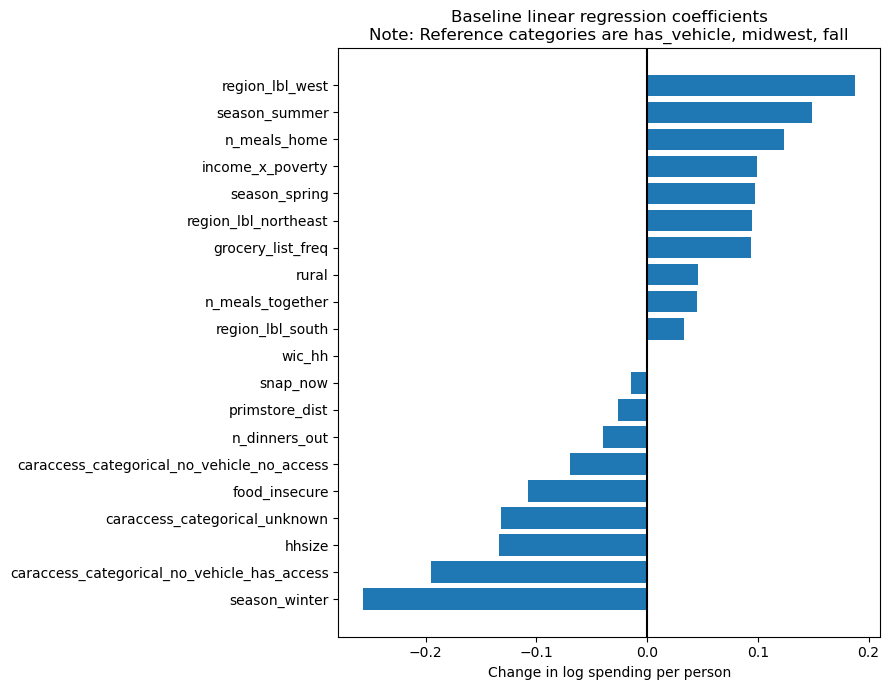

In [51]:
#Coefficients
#Note: features are standardized so magnitudes are comparable: change in log spending per 1 SD
linear_feature_names = get_feature_names(linear_pipeline.named_steps['preprocessor'])
linear_coefficients = pd.Series(linear_pipeline.named_steps['linear'].coef_, index=linear_feature_names).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(linear_coefficients.index, linear_coefficients.values)
ax.axvline(0, color='black')
ax.set_title('Baseline linear regression coefficients\nNote: Reference categories are has_vehicle, midwest, fall')
ax.set_xlabel('Change in log spending per person')
plt.tight_layout()
plt.show()

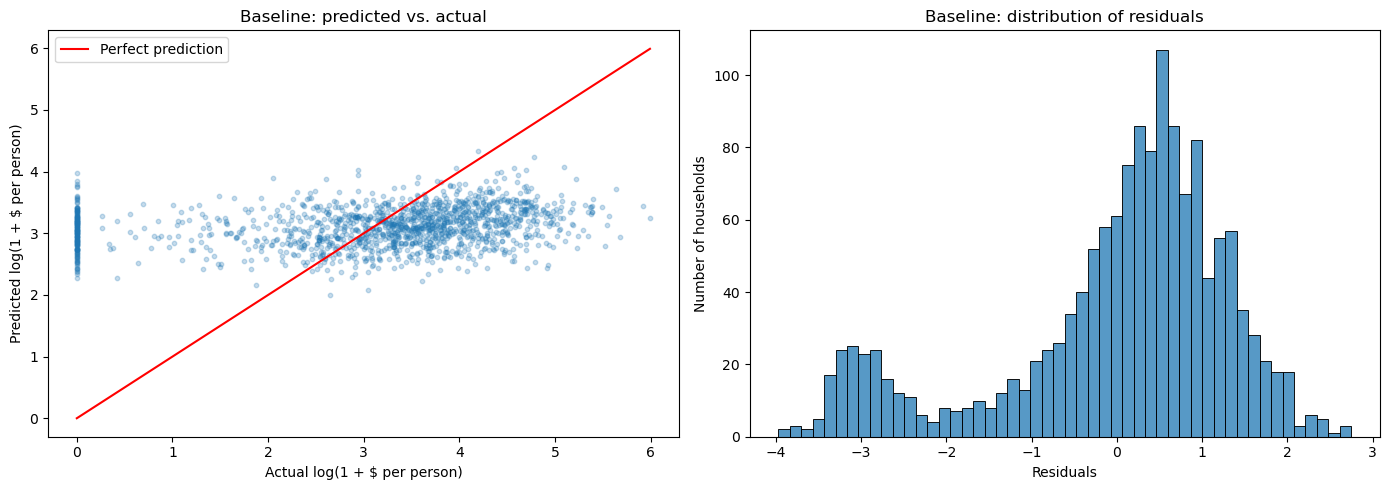

In [ ]:
#diagnostic plots -  predicted vs. actual and residual distribution on the test set
linear_test_predictions = linear_pipeline.predict(X_test)
residuals = y_test - linear_test_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, linear_test_predictions, alpha=0.25, s=10)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color='red',label='Perfect prediction')
axes[0].set_title('Baseline: predicted vs. actual')
axes[0].set_xlabel('Actual log(1 + $ per person)')
axes[0].set_ylabel('Predicted log(1 + $ per person)')
axes[0].legend()

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].set_title('Baseline: distribution of residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Number of households')
plt.tight_layout()
plt.show()

**Interpreting the baseline**
- Evaluation metrics: the baseline linear regression has a test MSE of 1.859 versus 1.969 for the naive mean model, which is about a 6% reduction in error. Its test R² is 0.055, meaning income, food-planning behaviors and the controls together explain about 6% of the household-to-household variation in weekly FAH spending per person. Train and test R² are close, so the model is not overfitting.
- An RMSE of 1.4 on the log scale is large and it means typical predictions are off by a multiplicative factor of several. The predicted-vs-actual plot shows thta the model predicts a narrow band and cannot reach the households with zero spending  which produce the separate cluster of residuals.
- More dinners prepared at home, higher income and more frequent grocery list use are each associated with higher FAH spending per person. Larger household size, food insecurity and eating out more are associated with lower spending. Households surveyed in winter spent less than those surveyed in fall, and households in the West spent more than those in the Midwest.

**9. Findings**

**Research question:** Are income, grocery-list use and other food planning behaviors associated with lower food-at-home (FAH) acquisition among US households?

**Preliminary answer:** they are associated with acquisition, but in the opposite direction from the hypothesis, and only modestly.

1. Higher income, more grocery-list use, and more meals prepared at home all go with more FAH acquisition, not less
2. Eating out more is associated with lower FAH acquisition
3. Household size, food insecurity, season and region matter at least as much as the income and planning variables. Larger households spend less per person (economies of scale), food-insecure households spend less, households surveyed in winter spent less, and Western households spent more.
4. Interpretation for the food-waste motivation: because FoodAPS measures acquisition rather than waste, higher spending among planners and home cooks does not by itself mean more waste. These households may simply eat more of their meals from food bought for home. A single week of acquisition data also captures a lot of noise where about 10% of households bought nothing that week, which limits how much any household characteristic can explain.

**10. Ideas for Next Steps**

- Model the zero spending weeks separately since about 10% of households had zero of FAH spending. A two part (hurdle) model with a classifier for whether a household acquired food that week plus a regression for how much among those that did spend should fit far better than one linear model.
- Try Ridge and Lasso alpha grids, and try tree based models (random forest, gradient boosting) that capture interactions such as income × grocery list use.
- Use cross validation for final model selection rather than a single train/test split